## Lab 2: Grayscale Medical Image CNN
Name: Arnav Narula
Reg No: 2547115

In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import zipfile
import os

# Extract data if needed
if not os.path.exists('chest_xray'):
    with zipfile.ZipFile('data.zip', 'r') as zip_ref:
        zip_ref.extractall()

In [9]:
import glob
image_paths = glob.glob('chest_xray/train/NORMAL/*.jpeg')
img_path = image_paths[0]
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, (128, 128))
img_normalized = img_resized / 255.0
img_tensor = tf.convert_to_tensor(img_normalized, dtype=tf.float32)
img_tensor = tf.expand_dims(img_tensor, axis=-1)
img_tensor = tf.expand_dims(img_tensor, axis=0)
print('Tensor shape:', img_tensor.shape)

Tensor shape: (1, 128, 128, 1)


### CNN Architecture

In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(128, 128, 1)),
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', name='conv1'),
    tf.keras.layers.MaxPooling2D(2, 2, name='pool1'),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', name='conv2'),
    tf.keras.layers.MaxPooling2D(2, 2, name='pool2'),
    tf.keras.layers.Flatten(name='flatten'),
    tf.keras.layers.Dense(64, activation='relu', name='dense_latent')
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 126, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_latent (Dense)            │ (None, 64)             │     1,843,264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,848,064 (7.05 MB)

 Trainable params: 1,848,064 (7.05 MB)

 Non-trainable params: 0 (0.00 B)

### Extract and Visualize Features

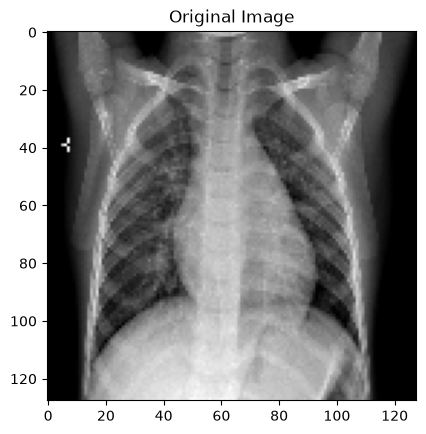

Feature Map: conv1, Shape: (1, 126, 126, 16)


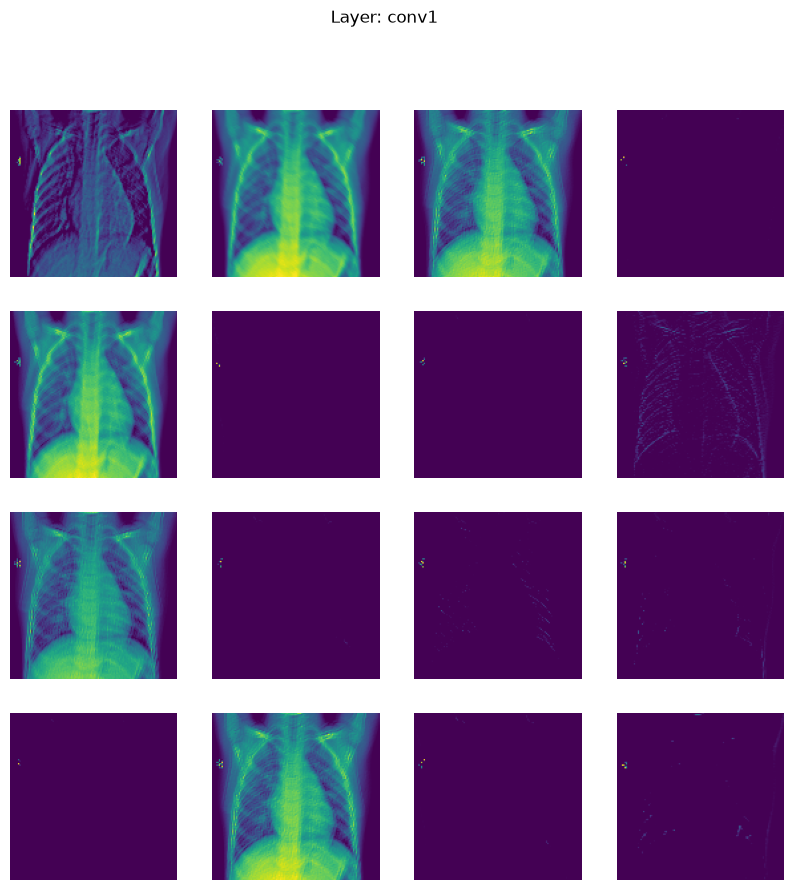

Feature Map: pool1, Shape: (1, 63, 63, 16)


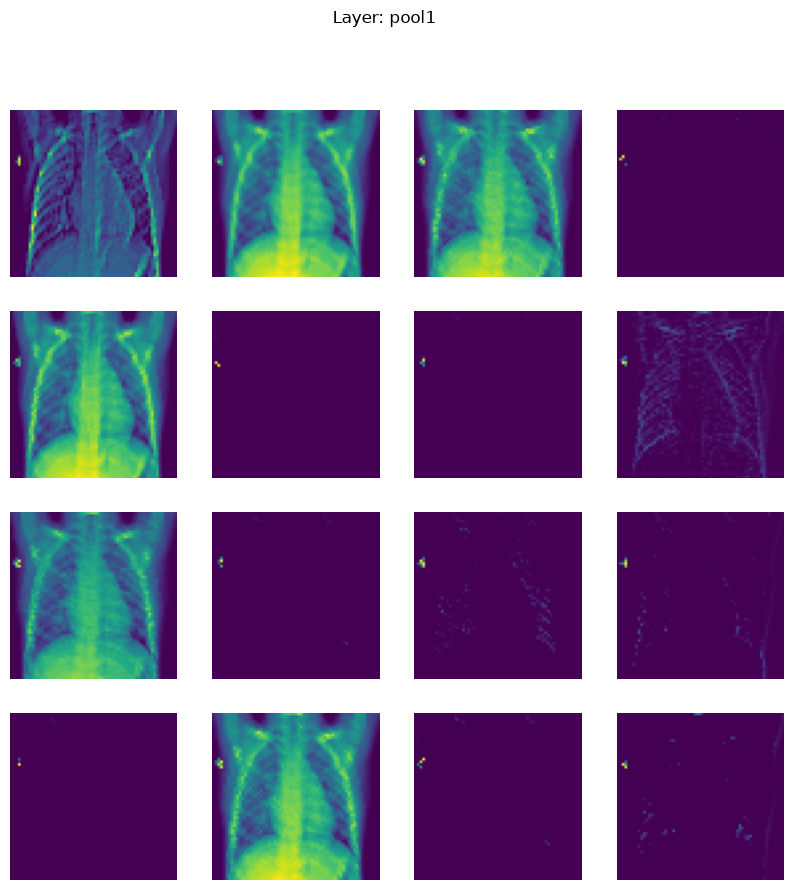

Feature Map: conv2, Shape: (1, 61, 61, 32)


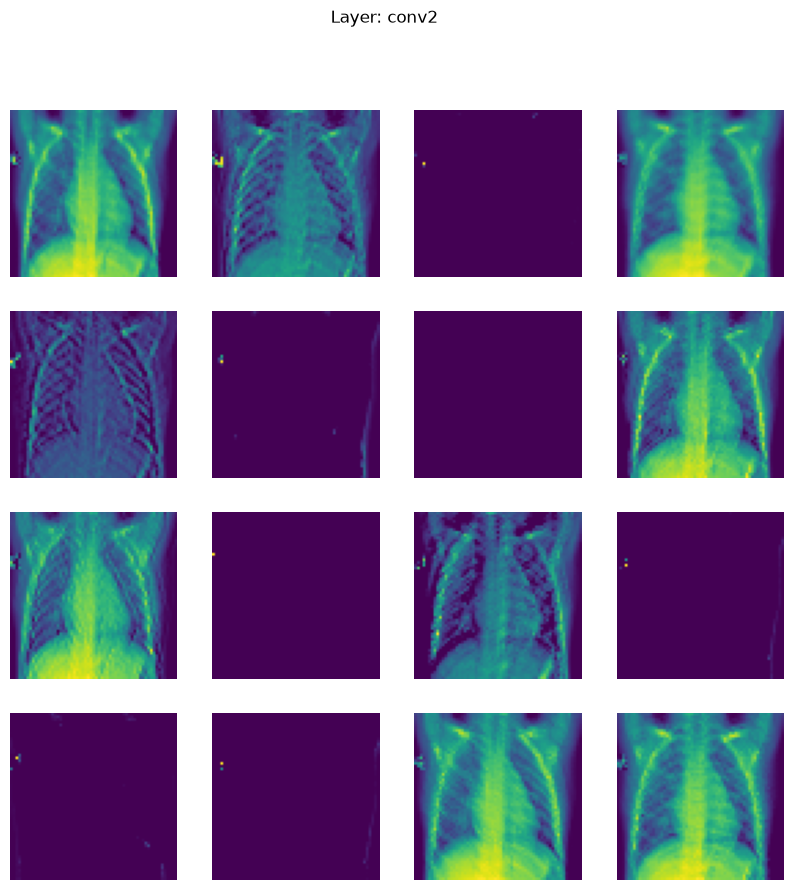

Feature Map: pool2, Shape: (1, 30, 30, 32)


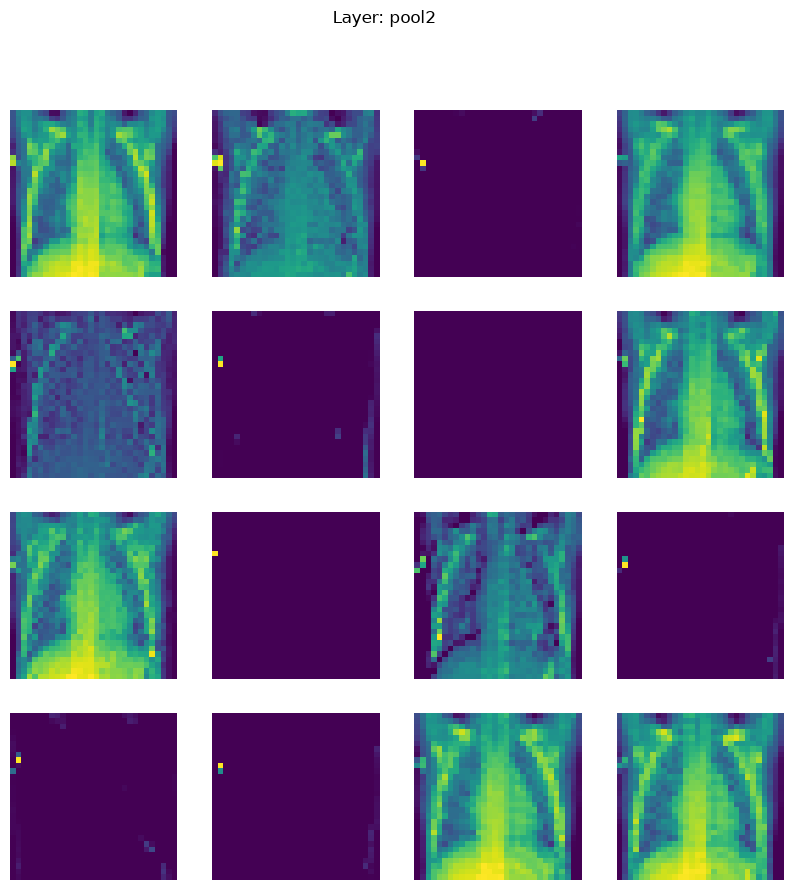

Latent Vector: [[0.         0.         0.14653581 0.         0.00131164 0.
  0.         0.         0.         0.05834502 0.         0.
  0.00414173 0.14395982 0.0544256  0.04594463 0.         0.0090038
  0.         0.03298322 0.         0.06666046 0.         0.
  0.0354209  0.         0.         0.03284147 0.         0.1736622
  0.07611555 0.07301383 0.15937272 0.13185556 0.         0.
  0.01341686 0.01816533 0.07476183 0.0042433  0.         0.
  0.06157158 0.02249628 0.18313034 0.03276639 0.229996   0.09198337
  0.         0.03806039 0.00026018 0.00624044 0.         0.02994292
  0.09445947 0.         0.         0.         0.07463424 0.
  0.         0.12278502 0.         0.05938415]]


In [11]:
layer_names = [layer.name for layer in model.layers if 'conv' in layer.name or 'pool' in layer.name]
feature_extractor = tf.keras.Model(inputs=model.inputs, outputs=[model.get_layer(name).output for name in layer_names] + [model.get_layer('dense_latent').output])
features = feature_extractor(img_tensor)
latent_vector = features[-1]
feature_maps = features[:-1]

plt.imshow(img_resized, cmap='gray')
plt.title('Original Image')
plt.show()

for name, fmap in zip(layer_names, feature_maps):
    print(f'Feature Map: {name}, Shape: {fmap.shape}')
    plt.figure(figsize=(10, 10))
    for i in range(min(16, fmap.shape[-1])):
        plt.subplot(4, 4, i+1)
        plt.imshow(fmap[0, :, :, i], cmap='viridis')
        plt.axis('off')
    plt.suptitle(f'Layer: {name}')
    plt.show()

print('Latent Vector:', latent_vector.numpy())

### Custom Filter Application (Complexity Element)

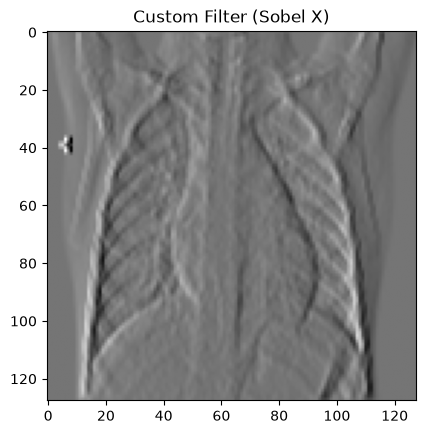

In [12]:
sobel_x = tf.constant([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=tf.float32)
sobel_x = tf.reshape(sobel_x, (3, 3, 1, 1))
custom_conv = tf.nn.conv2d(img_tensor, sobel_x, strides=[1, 1, 1, 1], padding='SAME')
plt.imshow(custom_conv[0, :, :, 0], cmap='gray')
plt.title('Custom Filter (Sobel X)')
plt.show()